In [149]:
!git clone https://github.com/Alexander-ha/regressors_tests_TESISFORK.git

fatal: destination path 'regressors_tests_TESISFORK' already exists and is not an empty directory.


In [150]:
import sys
sys.path.append("/content/regressors_tests_TESISFORK")

In [151]:
sys.path.append("/content/regressors_tests_TESISFORK/bin")

In [152]:
!pip install pyDOE3

In [153]:
# Импортируем нужные библиотеки
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split # класс разбиения на данные для обучения и для проверки
from sklearn.preprocessing import MinMaxScaler
# импортируем функции
from functions import plot_true_vs_predicted,  Functions, Generate_natural_data, Generate_coded_data

In [154]:
class UniversalTargetGenerator:
    '''
    Данный класс представляет из себя универсальный генератор целевых переменных для всех возможных функций использующихся в данной библиотеке.
    '''
    def __init__(self, main_function, features, rng=None):
        self.main_function = main_function
        self.features = features
        self.rng = rng if rng is not None else np.random.default_rng(main_function.random_seed)
        self.n_features = main_function.n_features
        self.target = None

    def gentarget(self):
        '''
        Данный метод генерирует таргеты в зависимости от размерности задачи. Размерности задачи уточняется
        по классу функции и по ее внутренним аргументам
        '''
        n_samples=self.features.shape[0]
        self.target = np.zeros(n_samples)

        for i in range(n_samples):
            if self.n_features == 1:
                x1 = self.features[i, 0]
                self.target[i] = self.main_function.main_function(x1)
            elif self.n_features == 2:
                x1, x2 = self.features[i, 0], self.features[i, 1]
                self.target[i] = self.main_function.main_function(x1, x2)
            elif self.n_features == 3:
                x1, x2, x3 = self.features[i, 0], self.features[i, 1], self.features[i, 2]
                self.target[i] = self.main_function.main_function(x1, x2, x3)
            elif self.n_features == 4:
                x1, x2, x3, x4 = self.features[i, 0], self.features[i, 1], self.features[i, 2], self.features[i, 3]
                self.target[i] = self.main_function.main_function(x1, x2, x3, x4)
            elif self.n_features == 5:
                x1, x2, x3, x4, x5 = (self.features[i, j] for j in range(5))
                self.target[i] = self.main_function.main_function(x1, x2, x3, x4, x5)
            elif self.n_features == 8:
                x1, x2, x3, x4, x5, x6, x7, x8 = (self.features[i, j] for j in range(8))
                self.target[i] = self.main_function.main_function(x1, x2, x3, x4, x5, x6, x7, x8)
            elif self.n_features == 10:
                x1, x2, x3, x4, x5, x6, x7, x8, x9, x10 = (self.features[i, j] for j in range(10))
                self.target[i] = self.main_function.main_function(x1, x2, x3, x4, x5, x6, x7, x8, x9, x10)
            else:
                args = [self.features[i, j] for j in range(self.n_features)]
                self.target[i] = self.main_function.main_function(*args)
        return self.target

    def evalp(self, point):
        '''
        Используется для задачи оракула:
        подали точку - получили информацию от оракула.
        '''
        point = np.asarray(point).flatten()
        if self.n_features == 1:
            return self.main_function.main_function(point[0])
        elif self.n_features == 2:
            return self.main_function.main_function(point[0], point[1])
        elif self.n_features == 3:
            return self.main_function.main_function(point[0], point[1], point[2])
        elif self.n_features == 4:
            return self.main_function.main_function(point[0], point[1], point[2], point[3])
        elif self.n_features == 5:
            return self.main_function.main_function(*point[:5])
        elif self.n_features == 8:
            return self.main_function.main_function(*point[:8])
        elif self.n_features == 10:
            return self.main_function.main_function(*point[:10])
        else:
            return self.main_function.main_function(*point[:self.n_features])


In [155]:
main_functions = [] #объекты класса Functions
function_names = ['trigonometric', 'ackley', 'ridge_demo_8d'] # допустим сделали такой набор функций

for name in function_names:
  function=Functions()
  print(name)
  functions_dict = function.get_function_dict()
  if name not in functions_dict:
      raise ValueError(f"unknown func, availablea are:{list(functions_dict.keys())}")
  function.set_function(functions_dict[name])
  main_functions.append(function)

for function in main_functions: #checking
  print(function.main_function_name)


for item in main_functions:
    item.n_samples=4 #установка начальных сэмплов
    # пределы варьирования признаков
    item.limits = (-10, 10)

    # определяем вид функции
    # признаки переопределим с помощью ПФЭ
    data_generator = Generate_coded_data(item,item.n_samples,
                                  random_seed = item.random_seed)
    data_generator.set_matrix_type("lhs")
    item.features = data_generator.X_coded

    item.n_samples = data_generator.n_samples

trigonometric
ackley
ridge_demo_8d
trigonometric
ackley
ridge_demo_8d


In [156]:
for item in main_functions:
  rng = np.random.default_rng(seed=12345) #рандомный сид и значения для начального пулла
  X_pool = rng.uniform(low=-1.0, high=1.0, size=(10000, item.n_features))

In [157]:
for function in main_functions: #для всех функций из списка вызываем генератор целевых переменных и генерируем их
  target_generator = UniversalTargetGenerator(function, function.features)
  function.target = target_generator.gentarget()


In [158]:
from sklearn.datasets import load_iris
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, WhiteKernel


In [159]:
for function in main_functions: #генерируем тестовую сетку чтобы сравнивать
  def create_test_grid(n_points=1000, n_features=3, seed=999):
    rng_test = np.random.default_rng(seed=seed)
    X_test = rng_test.uniform(low=-1.0, high=1.0, size=(n_points, n_features))
    test_generator = UniversalTargetGenerator(function, X_test)
    y_test = test_generator.gentarget()
    return X_test, y_test

  X_test, y_test = create_test_grid(2000, function.n_features)
  print(f"test samples for function {function.main_function_name}: {X_test.shape}, {y_test.shape}")


test samples for function trigonometric: (2000, 3), (2000,)
test samples for function ackley: (2000, 3), (2000,)
test samples for function ridge_demo_8d: (2000, 8), (2000,)


In [160]:
from scipy import stats
from sklearn.gaussian_process import GaussianProcessRegressor


In [161]:
test_data_dict = {}
hyperparams = { #словарь функций и параметров в гауссовском процессе для низ
    'trigonometric': {
        'length_scale': 0.5,
        'noise_level': 0.01
    },
    'ackley': {
        'length_scale': 2.0,
        'noise_level': 0.0001   # шум поменьше
    },
    'ridge_demo_8d': {
        'length_scale': 1.0,
        'noise_level': 0.01
    }
}


results={}
for function in main_functions:
    print(f'learning: {function.main_function_name}')
    rng = np.random.default_rng(seed=12345)
    X_pool = rng.uniform(low=-1.0, high=1.0, size=(10000, function.n_features))

    # СОЗДАЕМ ТЕСТОВУЮ ВЫБОРКУ ОДИН РАЗ И СОХРАНЯЕМ
    def create_test_grid(n_points=1000, n_features=3, seed=999):
        rng_test = np.random.default_rng(seed=seed)
        X_test = rng_test.uniform(low=-1.0, high=1.0, size=(n_points, n_features))
        test_generator = UniversalTargetGenerator(function, X_test)
        y_test = test_generator.gentarget()
        return X_test, y_test

    X_test, y_test = create_test_grid(2000, function.n_features)
    test_data_dict[function.main_function_name] = (X_test, y_test)

    target_generator = UniversalTargetGenerator(function, function.features)
    if function.target is None:
        function.target = target_generator.gentarget()

    n_active_iterations = 15
    history = []
    history_scores = []
    entropy_history = [] #параметры
    n_models = 3
    n_points_to_add = 5
    if function.main_function_name == 'ackley':
            n_points_to_add = 20#
            n_active_iterations = 15


    for iteration in range(n_active_iterations):
        predictions = []
        scores = []
        entropies = []

        for i in range(n_models):
            params = hyperparams.get(function.main_function_name, {'length_scale': 0.5, 'noise_level': 0.01})
            kernel = 1.0 * RBF(length_scale=params['length_scale']) + WhiteKernel(noise_level=params['noise_level'])
            model = GaussianProcessRegressor(kernel=kernel, random_state=i+228)

            model.fit(np.array(function.features), np.array(function.target)) #
            scores.append(model.score(function.features, function.target)) #сохраняем метрики
            pred, covmat = model.predict(X_pool, return_cov=True) #тестим модель предиктом на пулах
            variances = np.diag(covmat)#получаем ковариации тк дисперсия(Х)=ковариация(Х,х)
            variances = np.maximum(variances, 1e-10)
            margentro = 0.5 * np.log(2 * np.pi * np.e * variances) #считаем маргинальную энтропию
            entropies.append(margentro)
            predictions.append(pred)

        predictions = np.array(predictions)
        entropies = np.array(entropies)
        uncertainty = predictions.std(axis=0)
        pred_entropies = np.mean(entropies, axis=0)

        uncertainty_index = np.argsort(pred_entropies)[::-1][:n_points_to_add]
        entropy_history.append(np.mean(margentro))
        history_scores.append(np.mean(scores))

        for idx in uncertainty_index:
            features_to_add = X_pool[idx:idx+1] #добавляем новые признаки
            target_to_add = target_generator.evalp(features_to_add[0]) #генерируем таргеты по признакам

            history.append({
                'iter': iteration,
                'features': features_to_add,
                'target': target_to_add,
                'score': np.mean(scores),
                'total entropy': np.mean(pred_entropies)
            })

            function.features = np.vstack([function.features, features_to_add])
            function.target = np.append(function.target, target_to_add)

        X_pool = np.delete(X_pool, uncertainty_index, axis=0)

        print(f"choosen points:")
        for j, idx in enumerate(uncertainty_index[:3]):
            print(f"  point: {X_pool[idx] if idx < len(X_pool) else features_to_add[0][:3]}...")
        print(f"entropy: {pred_entropies[uncertainty_index][:3]}")
        kernel = 1.0 * RBF(length_scale=params['length_scale']) + WhiteKernel(noise_level=params['noise_level'])
        temp_model = GaussianProcessRegressor(kernel=kernel, random_state=i+228)
        temp_model.fit(function.features, function.target)
        y_pred_temp = temp_model.predict(X_test)  # используем ТУ ЖЕ тестовую выборку
        rmse_current = np.sqrt(mean_squared_error(y_test, y_pred_temp))
        r2_current = r2_score(y_test, y_pred_temp)
        print(f"RMSE test: {rmse_current:.4f}")
        print(f"R2 test: {r2_current:.4f}")
        results[function.main_function_name] = {
        'entropy_history': entropy_history,
        'history_scores': history_scores
    }


learning: trigonometric
choosen points:
  point: [-0.31243041 -0.04394184 -0.04389778]...
  point: [-0.95776665  0.83108786  0.55428449]...
  point: [-0.26832964 -0.7377868  -0.58964896]...
entropy: [-0.62862949 -0.6286295  -0.6286295 ]
RMSE test: 0.3458
R2 test: -0.0438
choosen points:
  point: [ 0.55202615  0.73654173 -0.0456835 ]...
  point: [ 0.8294401   0.96055467 -0.1963063 ]...
  point: [ 0.42462243 -0.9775533   0.42569012]...
entropy: [0.4179695  0.41795873 0.41789313]
RMSE test: 0.3490
R2 test: -0.0633
choosen points:
  point: [ 0.62604211 -0.04090361  0.02526223]...
  point: [ 0.42809477 -0.23490382  0.17239828]...
  point: [-0.5169445  -0.70867262 -0.92382307]...
entropy: [0.65097332 0.65096695 0.65095721]
RMSE test: 0.3478
R2 test: -0.0556
choosen points:
  point: [ 0.83942411 -0.7098735   0.4589093 ]...
  point: [-0.21330187  0.69914677  0.63468462]...
  point: [-0.69156388 -0.16327742  0.75676422]...
entropy: [0.71590311 0.71583112 0.71574769]
RMSE test: 0.3416
R2 test: -

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning:

choosen points:
  point: [ 0.64111183 -0.07407612 -0.61595452]...
  point: [-0.82092653  0.21565981 -0.00451888]...
  point: [ 0.21715564  0.32032783 -0.07262977]...
entropy: [0.64278606 0.64083327 0.64064551]
RMSE test: 0.2357
R2 test: 0.5152
choosen points:
  point: [ 0.47855837 -0.70328975  0.69543697]...
  point: [-0.28704516  0.50369718 -0.50051951]...
  point: [-0.26919385 -0.36167712  0.76876285]...
entropy: [0.76287456 0.76038901 0.75447202]


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


RMSE test: 0.0880
R2 test: 0.9324


...

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_pro

choosen points:
  point: [-0.01896319 -0.39337253 -0.88125901  0.90120727 -0.10972168 -0.53571334
  0.07184751  0.84898595]...
  point: [ 0.13657738  0.34739019  0.00430897 -0.10391266 -0.76289125 -0.44681009
  0.72476115  0.79796213]...
  point: [-0.28159878  0.15325319 -0.45083912  0.48900206 -0.95755103 -0.41621211
  0.54285448  0.4596298 ]...
entropy: [-2.25311218 -2.26154428 -2.26501974]
RMSE test: 0.0005
R2 test: 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442:

choosen points:
  point: [-0.48535015 -0.61369259  0.87355457  0.46096282  0.61473334  0.88597313
 -0.47895775 -0.01161559]...
  point: [-0.95101867 -0.3980706   0.63628209  0.45683326  0.7094159  -0.02151968
  0.79191501 -0.18726887]...
  point: [ 7.04937524e-01  3.87051724e-01  2.09752561e-04  2.49860704e-01
  7.51639746e-01  7.19419626e-01 -9.98011697e-02 -8.15490136e-01]...
entropy: [-2.4150939  -2.42001925 -2.43161653]
RMSE test: 0.0004
R2 test: 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [162]:
def visualize_results(main_function, final_model, X_test, y_test, y_pred, entropy, rmse, r2, function_name):
    """визуализация фнукции"""

    fig = plt.figure(figsize=(16, 5))

    # entropy
    ax1 = fig.add_subplot(131)
    if len(entropy) > 0:
        ax1.plot(range(1, len(entropy)+1), entropy, 'b-o', linewidth=2, markersize=4)
    ax1.set_xlabel('iter')
    ax1.set_ylabel('entropy')
    ax1.set_title(f'entropy (final: {entropy[-1] if entropy else 0:.3f})')
    ax1.grid(True, alpha=0.3)

    # metrics
    ax2 = fig.add_subplot(132)
    metrics = ['rmse', 'r2']
    values = [rmse, r2]
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in values]
    bars = ax2.bar(metrics, values, color=colors, edgecolor='black', linewidth=1)
    ax2.set_ylabel('value')
    ax2.set_title(f'{function_name}\rmse={rmse:.3f}, r2={r2:.3f}')
    ax2.set_ylim(0, max(1.0, max(values) * 1.2))
    for bar, val in zip(bars, values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')

    if main_function.n_features == 2 or main_function.n_features == 3:
        ax3 = fig.add_subplot(133, projection='3d')
        n_grid = 30

        if main_function.n_features == 2:
            x1_grid = np.linspace(-1, 1, n_grid)
            x2_grid = np.linspace(-1, 1, n_grid)
            X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
            Z_pred = np.zeros((n_grid, n_grid))
            Z_true = np.zeros((n_grid, n_grid))

            for i in range(n_grid):
                for j in range(n_grid):
                    Z_pred[i, j] = final_model.predict([[X1_grid[i, j], X2_grid[i, j]]])[0]
                    Z_true[i, j] = main_function.main_function(X1_grid[i, j], X2_grid[i, j])

            surf = ax3.plot_surface(X1_grid, X2_grid, Z_pred, cmap='viridis', alpha=0.7)
            ax3.scatter(main_function.features[:, 0], main_function.features[:, 1],
                       main_function.target, c='red', s=15, alpha=0.5, label='learning points')
            ax3.set_xlabel('x1')
            ax3.set_ylabel('x2')
            ax3.set_zlabel('f(x1,x2)')

        elif main_function.n_features == 3:
            # fix x3=0 slize
            x1_grid = np.linspace(-1, 1, n_grid)
            x2_grid = np.linspace(-1, 1, n_grid)
            X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)

            Z_pred = np.zeros((n_grid, n_grid))
            Z_true = np.zeros((n_grid, n_grid))

            for i in range(n_grid):
                for j in range(n_grid):
                    Z_pred[i, j] = final_model.predict([[X1_grid[i, j], X2_grid[i, j], 0]])[0]
                    Z_true[i, j] = main_function.main_function(X1_grid[i, j], X2_grid[i, j], 0)

            surf = ax3.plot_surface(X1_grid, X2_grid, Z_pred, cmap='viridis', alpha=0.7)
            ax3.scatter(main_function.features[:, 0], main_function.features[:, 1],
                       main_function.target, c='red', s=15, alpha=0.5, label='Обучающие точки')
            ax3.set_xlabel('x1')
            ax3.set_ylabel('x2')
            ax3.set_zlabel('f(x1,x2,0)')

        ax3.set_title(f'predicted surface (R²={r2:.3f})')
        ax3.legend(loc='upper left', fontsize=7)
        ax3.view_init(elev=25, azim=-60)

    plt.tight_layout()
    plt.show()

    if main_function.n_features == 2 or main_function.n_features == 3:
        fig2 = plt.figure(figsize=(16, 5))
        ax1_real = fig2.add_subplot(121, projection='3d')
        n_grid = 30

        if main_function.n_features == 2:
            x1_grid = np.linspace(-1, 1, n_grid)
            x2_grid = np.linspace(-1, 1, n_grid)
            X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
            Z_true = np.zeros((n_grid, n_grid))

            for i in range(n_grid):
                for j in range(n_grid):
                    Z_true[i, j] = main_function.main_function(X1_grid[i, j], X2_grid[i, j])

            surf_real = ax1_real.plot_surface(X1_grid, X2_grid, Z_true, cmap='plasma', alpha=0.8)
            ax1_real.set_xlabel('x1')
            ax1_real.set_ylabel('x2')
            ax1_real.set_zlabel('f(x1,x2)')
            ax1_real.set_title(f'Real surface: {function_name}')

        elif main_function.n_features == 3:
            x1_grid = np.linspace(-1, 1, n_grid)
            x2_grid = np.linspace(-1, 1, n_grid)
            X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
            Z_true = np.zeros((n_grid, n_grid))

            for i in range(n_grid):
                for j in range(n_grid):
                    Z_true[i, j] = main_function.main_function(X1_grid[i, j], X2_grid[i, j], 0)

            surf_real = ax1_real.plot_surface(X1_grid, X2_grid, Z_true, cmap='plasma', alpha=0.8)
            ax1_real.set_xlabel('x1')
            ax1_real.set_ylabel('x2')
            ax1_real.set_zlabel('f(x1,x2,0)')
            ax1_real.set_title(f'Real surface (x3=0): {function_name}')

        ax1_real.view_init(elev=25, azim=-60)
        plt.colorbar(surf_real, ax=ax1_real, shrink=0.6)
        ax2_compare = fig2.add_subplot(122, projection='3d')

        if main_function.n_features == 2:
            Z_pred = np.zeros((n_grid, n_grid))
            for i in range(n_grid):
                for j in range(n_grid):
                    Z_pred[i, j] = final_model.predict([[X1_grid[i, j], X2_grid[i, j]]])[0]
        else:
            Z_pred = np.zeros((n_grid, n_grid))
            for i in range(n_grid):
                for j in range(n_grid):
                    Z_pred[i, j] = final_model.predict([[X1_grid[i, j], X2_grid[i, j], 0]])[0]

        Z_diff = np.abs(Z_true - Z_pred)

        surf_compare = ax2_compare.plot_surface(X1_grid, X2_grid, Z_diff, cmap='hot', alpha=0.8)
        ax2_compare.set_xlabel('x1')
        ax2_compare.set_ylabel('x2')
        ax2_compare.set_zlabel('|true - pred|')
        ax2_compare.set_title(f'Absolute error (max={np.max(Z_diff):.3f})')
        ax2_compare.view_init(elev=25, azim=-60)
        plt.colorbar(surf_compare, ax=ax2_compare, shrink=0.6)

        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.6, label='pred')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='ideal line')
    plt.xlabel('real vals')
    plt.ylabel('pred vals')
    plt.title(f'{function_name}: real vs pred (R²={r2:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Visualization for: trigonometric


) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


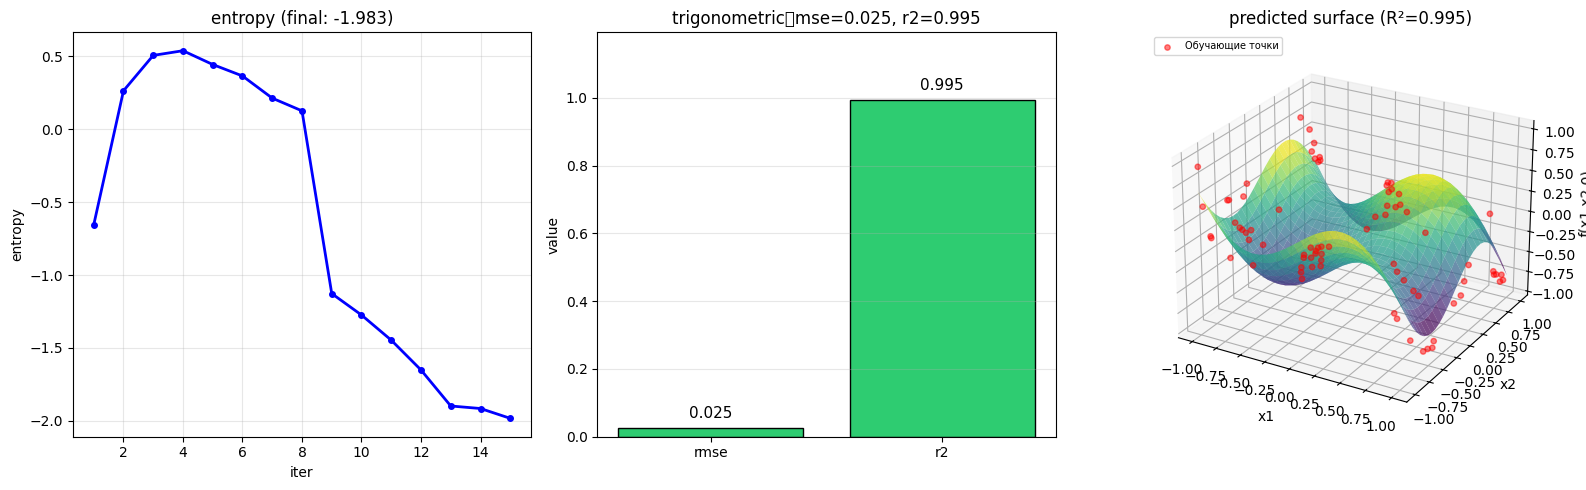

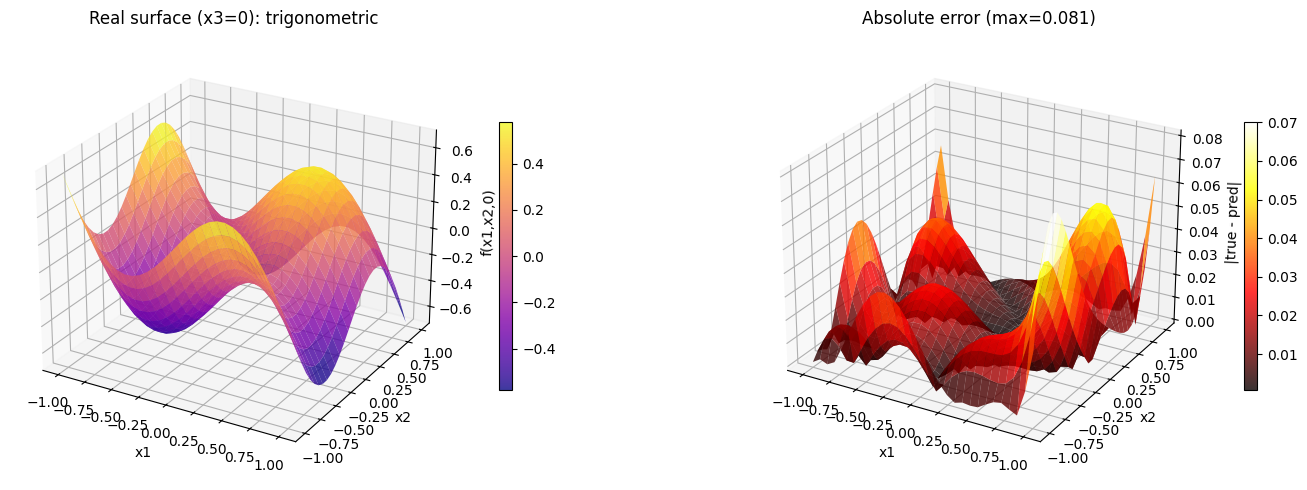

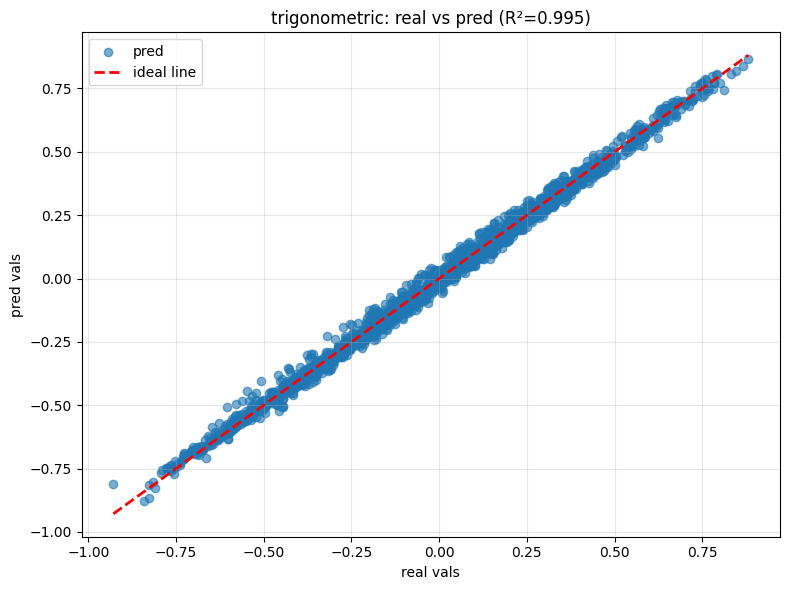


Visualization for: ackley


) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


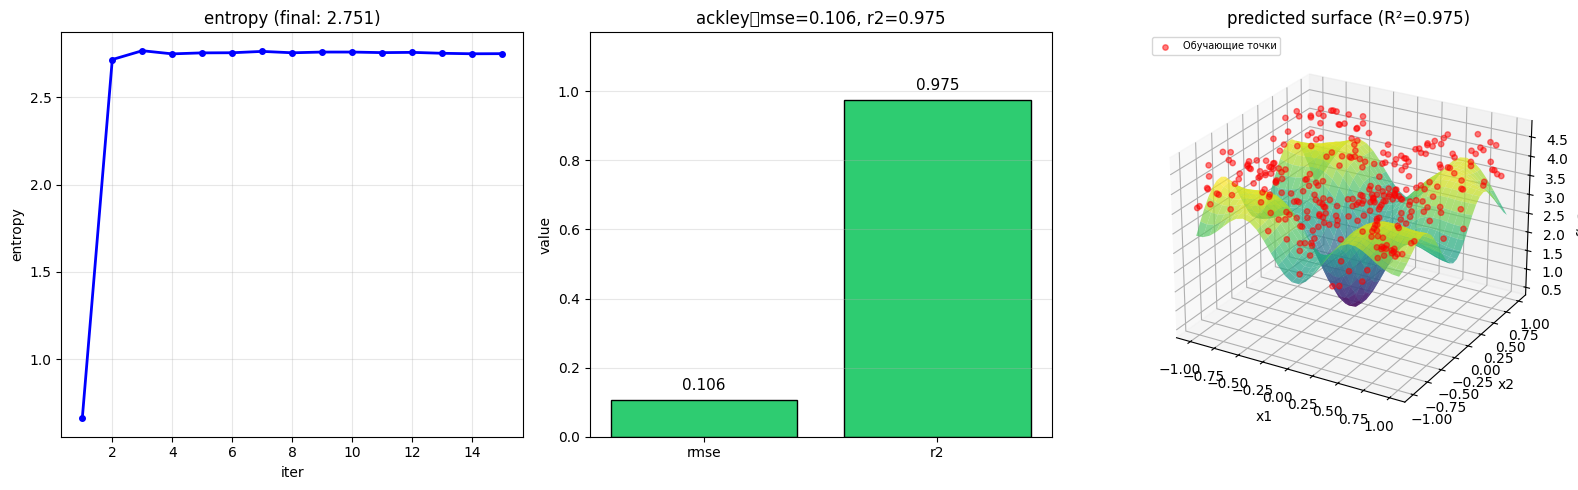

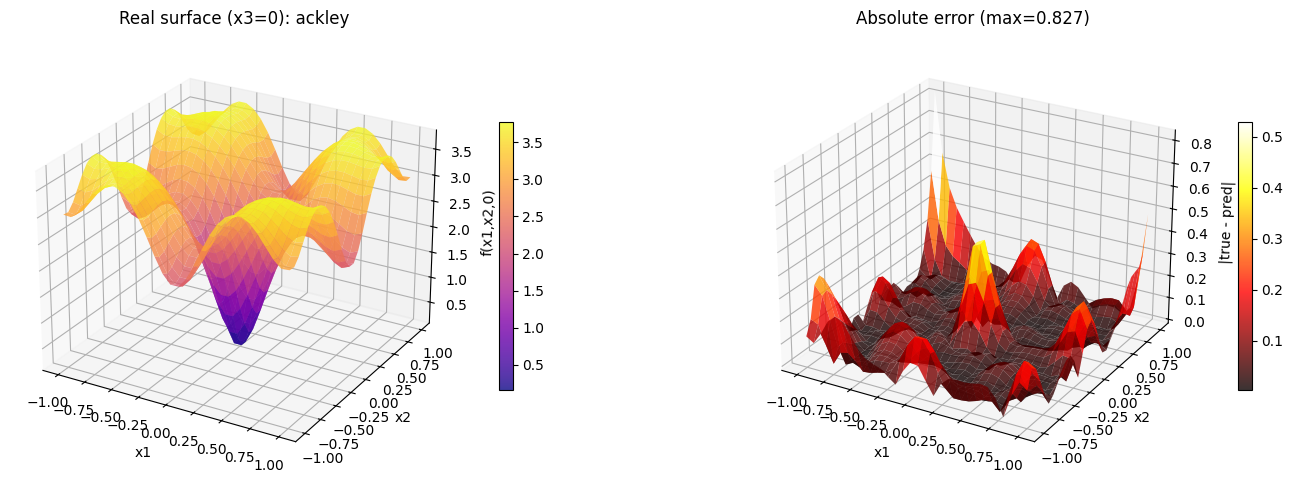

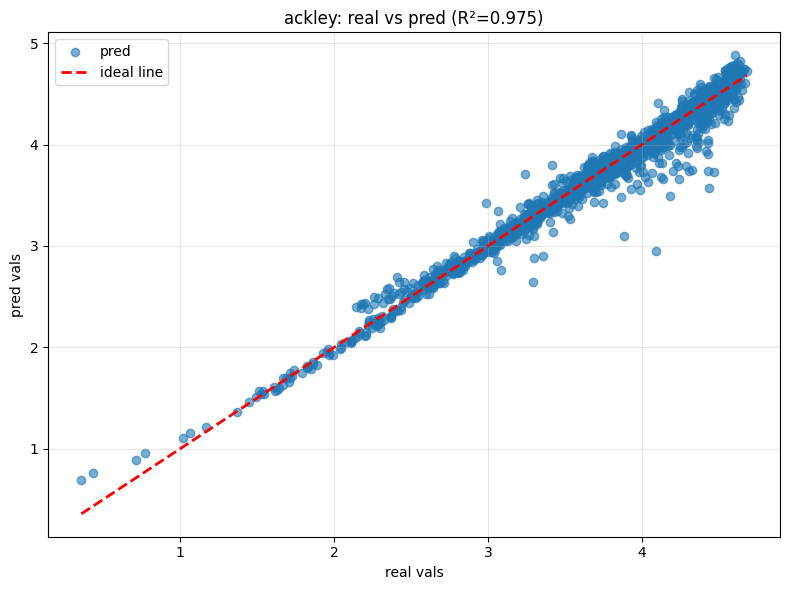


Visualization for: ridge_demo_8d


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


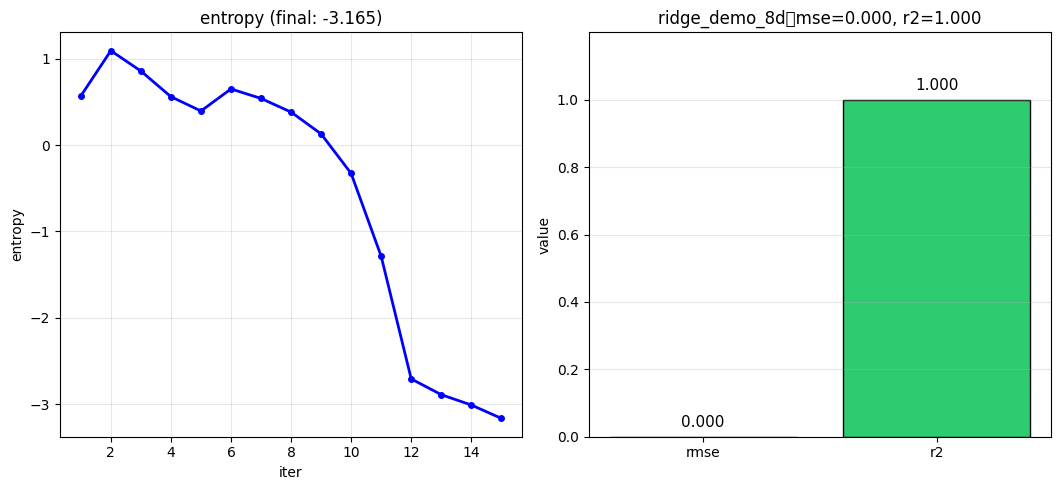

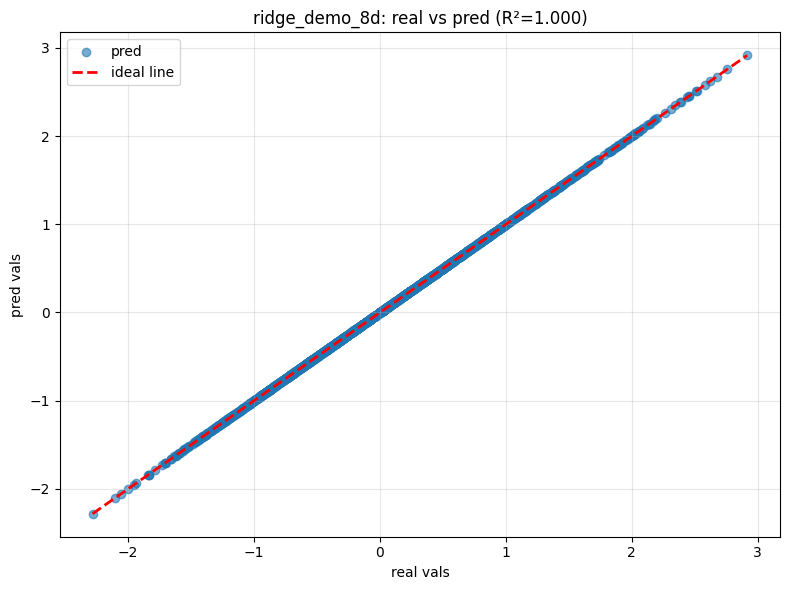

In [163]:
for function in main_functions:
    print(f"\nVisualization for: {function.main_function_name}")

    # та же тестовая выборка берем и предсказываем для визуализации
    X_test, y_test = test_data_dict[function.main_function_name]

    final_model = GaussianProcessRegressor(
        kernel=1.0 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.01),
        random_state=42
    )
    final_model.fit(function.features, function.target)
    y_pred = final_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    entropy_history = results.get(function.main_function_name, {}).get('entropy_history', [])

    visualize_results(
        main_function=function,
        final_model=final_model,
        X_test=X_test,
        y_test=y_test,
        y_pred=y_pred,
        entropy=entropy_history,
        rmse=rmse,
        r2=r2,
        function_name=function.main_function_name
    )
